In [2]:
import librosa
import librosa.display
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# load audio files
audio_file = "./file_example_WAV_1MG.wav"

ipd.Audio(audio_file)

audio, _ = librosa.load(audio_file, mono=True)

In [12]:
# extract RMSE with librosa

FRAME_SIZE = 1024
HOP_LENGTH = 512

rms_audio = librosa.feature.rms(y=audio, frame_length=FRAME_SIZE, hop_length=HOP_LENGTH)[0]
rms_audio.shape


(256,)

In [16]:
def rms(signal, frame_length, hop_length):
    rms = []

    for i in range(0, len(signal), hop_length):
        rms_current_frame = np.sqrt(np.sum(signal[i: i+frame_length]**2) / frame_length)
        rms.append(rms_current_frame)
    
    return np.array(rms)

rms1_audio = rms(audio, frame_length=FRAME_SIZE, hop_length=HOP_LENGTH)

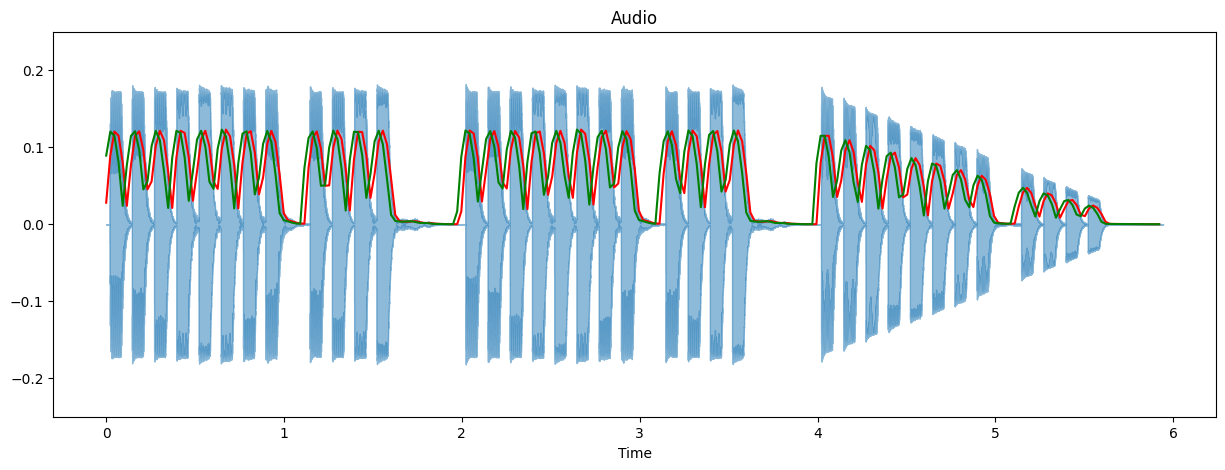

In [18]:
# plot the RMSE

frames = range(len(rms_audio))
t = librosa.frames_to_time(frames, hop_length=HOP_LENGTH)

plt.figure(figsize=(15, 17))

plt.subplot(3, 1, 1)
librosa.display.waveshow(audio, alpha=0.5)
plt.plot(t, rms_audio, color='r')
plt.plot(t, rms1_audio, color='g')
plt.title("Audio")
plt.ylim(-0.25, 0.25)

plt.show()

In [23]:
# Zero-crossing Rate

zcr_audio = librosa.feature.zero_crossing_rate(audio, frame_length=FRAME_SIZE, hop_length=HOP_LENGTH)[0]

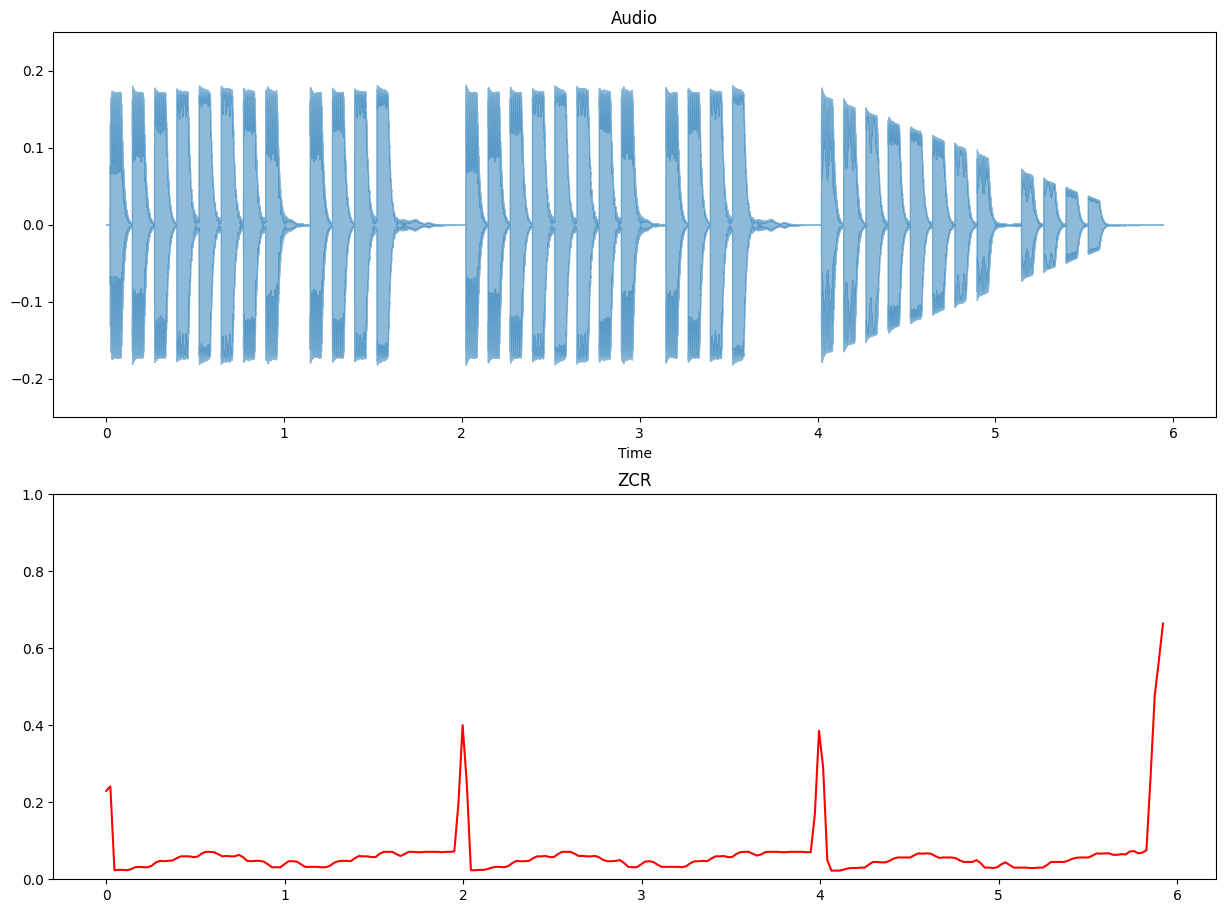

In [29]:
# Visualise ZCR

frames = range(len(rms_audio))
t = librosa.frames_to_time(frames, hop_length=HOP_LENGTH)

plt.figure(figsize=(15, 17))

plt.subplot(3, 1, 1)
librosa.display.waveshow(audio, alpha=0.5)
plt.title("Audio")
plt.ylim(-0.25, 0.25)

plt.subplot(3, 1, 2)
plt.plot(t, zcr_audio, color='r')
plt.title("ZCR")
plt.ylim(0, 1)

plt.show()
